# 计算机图形学笔记

20251114

## 第一章 绪论

### 1. 图像学和图形学的区别

### 2. 走样的原因
  
  用离散量表示连续量引起的失真.
### 3. 反走样的概念
  
  减少或消除因走样造成的阶梯形或闪烁的效果的方法称为反走样.反走样技术有:

  1. 前滤波:以较高的分辨率显示对象
  2. 后滤波:加权区域取样

### 4. 直线的扫描转换算法

对直线进行光栅化时,需要在显示器有限个象素中,确定最佳逼近该支线的一组象素,并且按照扫描线顺序,对这些象素进行写操作.这个过程称为显示器绘制直线或直线的扫描转换.

直线的扫描转换算法有:

- DDA算法
- 中点线算法
- Bresenham算法
  
#### 4.1 DDA算法

考虑到增量计算较快的原因，所以没有直接使用 y = kx+b的方法直接计算每个点的横纵坐标。而是使用 y(i) = y(i-1)+k △x  当△x  = 1的时候  y(i) = y(i-1)+k,这样只需要加法运算就可以求出每次的y值。
#### 4.2 Bresenham算法
  
  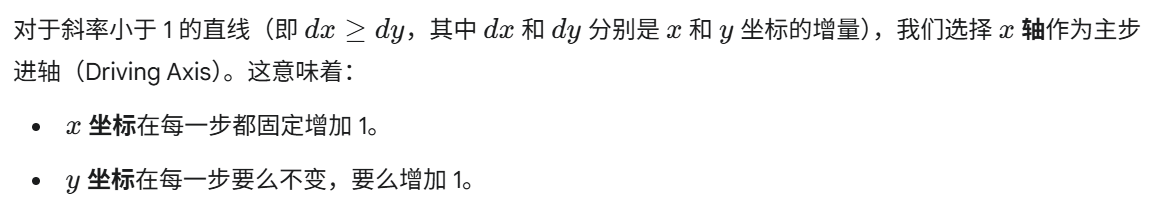

  以此种情况(即dx>dy)为例,每一步x坐标递增之后,y坐标要么不变(水平向右移动),要么以相同幅度递增(对角线方向移动).选择的规则如下:

  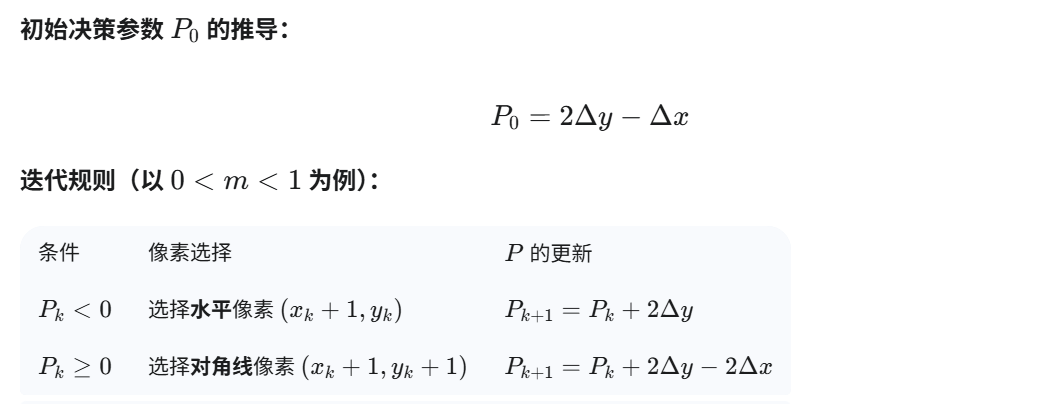

  **注:为了方便计算,可以提前算出两个方向(向右或向右上的)增量.**

  

## 第二章 颜色模型

### 1. 设备无关与设备相关
   - 设备无关的颜色模型:基于人眼对色彩感知的度量建立的数学模型,主要用于计算和测量.
   - 设备相关的颜色模型:以RGB模型为例,一组确定的RGB数值在一个液晶屏上显示,最终会作用到三色LED的电压上.这样一组值在不同设备上解释时,得到的颜色可能不同.
  
### 2. 设备相关与无关的模型例子
  在设备相关,不相关的颜色模型间互相转换,一般是以RGB和CIEXYZ作为桥梁进行的.
  
  - 相关:RGB,CMY,CMYK,HSV
  - 不相关: CIEXYZ

### 3. RGB模型和CMY模型之间的比较

| 比较维度 | RGB (Red, Green, Blue) | CMY (Cyan, Magenta, Yellow) |
| :--- | :--- | :--- |
| **物理原理** | 加色法 (Additive Color) | 减色法 (Subtractive Color) |
| **媒介本质** | 光 (发光体) | 颜料 / 油墨 (吸光物体) |
| **基础底色** | 黑色 (无光) | 白色 (全反射，如白纸) |
| **混合方向** | 颜色越加越亮 | 颜色越加越暗 |
| **最大混合** | R + G + B = 白色 | C + M + Y = 黑色 (理论值) |
| **主要应用** | 显示器、投影仪、相机、手机屏幕 | 打印机、胶印印刷、绘画 |印印刷、绘画、印刷、绘画

## 第三章 物体表示(1)-多边形表示:OBJ,BRep和半边数据结构

### 1.坐标系区别

- 世界坐标系: **场景参照坐标系,一个场景只有一个世界坐标系.** 是用于定义物体在场景中的位置.是一个大范围的参考,用来确定所有物体如何放置在这个虚拟世界中.

- 建模坐标系: **描述单个物体的形状,尺寸所采用的坐标系.** 是针对单个物体的.每个物体都是在它子集的坐标系中被创建和编辑的,就像是每件家具有自己的小平面图.这有助于设计者单独操作和调整每个模型,而不必担心其它模型或整个世界的坐标.

### 2.多边形表示方法:OBJ格式

保存: 1.几何信息.2.纹理信息.3.光线信息.

- 多边形表示的优点:
  + 表示简单.
  + 可以表示具有任意拓扑的物体.
  + 可以表示具有丰富细节的物体.
  + 大部分图形硬件支持多边形物体的加速绘制.
 
- 多边形表示的不足:
  + 逼近表示,难以满足交互时放大需求.
  + 难以用传统方法编辑物体外形.
  + 缺乏解析表达式,几何属性计算困难.
  + 在表示复杂拓扑和具有丰富细节的物体时,数据量庞大,建模/编辑/绘制/存储的负担重.

### 3.BREP表示

实体的边界通常由面的并集来表示;每个面又由他所在的曲面的定义加上其边界来表示,面的边界是边的并集;而边又是由点来表示的.

**BRep是什么?**

A:网格表示数据结构.

**BRep表示的两种类型**

A:1.拓扑信息(即网格之间的关系). 2.几何信息(网格坐标在哪里,大小是多少).

### 4.半边数据结构

- 每条边被记录为两条半边,记录每条半边:
  + 起始顶点的指针.
  + 邻接面的指针.(如果为边界,填充null)
  + (逆时针方向的)下一条半边.
  + 相邻的半边.
  + 前一条半边(可选).
  
- 面:
  边界上的一条半边.

- 顶点:
  + 坐标值.
  + 指向以此为起始端点的半边.

~~~C
struct HE_edge{
    HE_vert* vert; //起始顶点的指针
    HE_edge* pair; //相邻的半边:twin
    HE_face* face; //邻接面的指针
    HE_edge* next; //逆时针方向下一条半边
};
~~~

## 第三章 物体表示(2)参数曲面

### 1.参数表示的优点

- 参数表示是显示的
  - 对每一个参数值,可以直接计算曲面上的对应点.
  - 参数表示的物体可以很方便的转化为多边形逼近表示.
- 曲面上的几何量计算简便
- 特殊形式的参数表示的外形控制十分直观:
  - Bezier,B-样条,NURBS(非均匀有理B-样条)曲线/曲面.
 
### 2.Bezier曲线




## 第四章 Pipeline

### 1. Rendering Pipeline(渲染管道)

- **考点:掌握图形渲染通道的各部分和作用.**

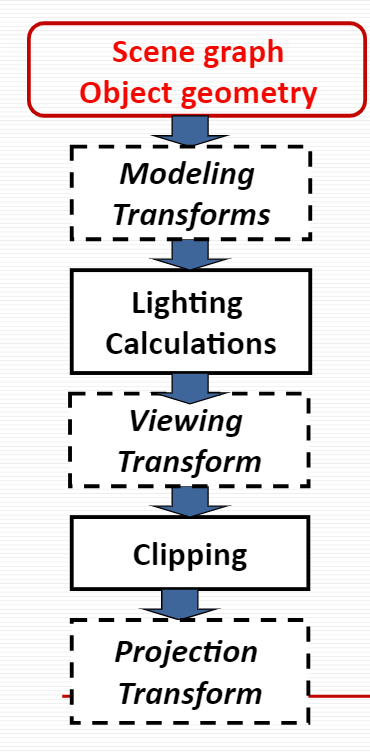

#### Modeling Transforms建模变换
    在建立或编辑三位模型时使用的.这些变换决定了模型的位置,旋转和缩放.可以理解为在虚拟世界中放置和调整模型的过程.

#### Lightning Calculations光照计算
    对场景中的所有几何图元进行照明处理,以模拟现实世界中的光照效果.过程中需要考虑以下几个光照参数:

  + 光源发射(Light source emission):涉及到光源的颜色和强度.包括如何发射光线等.例如点光源,聚光灯或环境光.
  + 表面反射率(Surface reflectance):每种材料不同的发射特性.决定了光线击中表面时反射的量,以及光线反射的方式,例如漫反射或镜面反射.
  + 大气衰减(Atmosphere attenuation):光线在通过介质时的强度减弱程度.
  + 相机响应(Camera response):模拟真实相机对光线的响应,比如光线如何被相机感光元件捕获并转换成图像.
 
    在光照计算过程中通常区分直接照明和全局照明.此处省略.

#### Viewing Transform视图变换
    视图变换的结果是:3D场景转换到视窗/相机坐标系.
    
    这样使得渲染出得图像符合从相机这一特定视角看到的场景.
    
#### Clipping裁剪

    结果:移除视图之外的几何体.

    这样做的好处是提高渲染效率,不必处理那些最终不会出现在最终图像上的数据.

    裁剪通常发生在将三维场景转换到二维图像之前的某个点,确保那些只有能被用户看到的物体才会进入下一步渲染流程.

#### Projection Transform投影转换

    结果:将裁剪后顶点的三维坐标转换为二维屏幕坐标.

    将三维场景的物体映射到二维屏幕上.主要的两种投影方式:

+ 透视投影:这种方式会模拟人眼观察现实世界的效果,远处的物体看起来会更小.
+ 正交投影:这种方式中,所有物体无论远近都保持相同的大小,通常用于工程图纸和建筑设计,因为它可以准确的保持物体的比例和角度.

#### Rasterize光栅化

    在渲染管线中,光栅化Rasterize负责将投影得到的2D图像转换为实际的象素(或点阵图).并确定那些像素将被渲染以及如何渲染.

+ 转换屏幕坐标到像素颜色:这意味着确定由三维物体边缘定义的线条或曲面在屏幕上应该覆盖哪些像素点,并为这些像素点着色.


## 第五章:变换

### 1. 齐次坐标系及其作用

    基本思想是:把一个n维空间的几何问题转换到n+1维空间.从形式上就是用一个n+1维向量表示一个n维空间中的点(向量).

比如:一个二维空间中的点$A(x,y)$的齐次坐标表示为$$(x\ast h,y\ast h,h),\forall h \neq 0.$$

齐次坐标表示不是唯一的.当$h=1$时,称为规格化齐次坐标.

**齐次坐标的作用**:可改写平移变换,缩放变换以及旋转变换为**统一的乘积形式**.

### 2. 二维平移,旋转,缩放矩阵

#### 平移变换

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
\\=\\
\begin{bmatrix}
1 & 0 & t_x \\ 
0 & 1 & t_y \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

$$ P'=T(t_x,t_y)\cdot P$$

**注:连续平移Translations是可加的**!即:

$$T(t_x2,t_y2) \cdot T(t_x1,t_y1) = T(t_x2 + t_x1 , t_y2+t_y1)$$

拓展到三维空间(四维)矩阵情况类似.

#### 旋转变换(坐标原点为旋转中心)

$$
\begin{bmatrix}
x' \\
y' \\
1 
\end{bmatrix}
\\=\\
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 \\
\sin\theta & \cos\theta & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1 \\
\end{bmatrix}
$$

**注:连续旋转可加**!即:

$$P' = R(\theta_1 + \theta_2) \cdot P$$

拓展到三维空间后,形式根据绕x,y,z轴有所不同.

绕z轴旋转(形式跟2维基本相同):
$$
R_z(\theta) = 
\begin{bmatrix}
\cos\theta & -\sin\theta & 0 & 0\\
\sin\theta & \cos\theta & 0 & 0\\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

绕x轴旋转:
$$
R_x(\theta) = 
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & \cos\theta & -\sin\theta & 0\\
0 & \sin\theta & \cos\theta & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

绕y轴旋转:
$$
R_y(\theta) = 
\begin{bmatrix}
\cos\theta & 0 & \sin\theta & 0\\
0 & 1 & 0 & 0\\
-\sin\theta & 0 & \cos\theta & 0 \\
0 & 0 & 0 & 1\\
\end{bmatrix}
$$

#### 缩放变换

$$
\begin{bmatrix}
x' \\
y' \\
1 
\end{bmatrix}
\\=\\
\begin{bmatrix}
S_x & 0 & 0 \\
0 & S_y & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
\cdot
\begin{bmatrix}
x \\
y \\
1 \\
\end{bmatrix}
$$

**注:连续缩放式相乘的**!不是叠加,即:

$$S(S_x2,S_y2) \cdot S(S_x1,S_y1) = S(S_x1 \cdot S_x2 , S_y1 \cdot S_y2)$$

拓展到三维空间类似.

**<mark>注意:因为对坐标变化时,原坐标向量在最右边.所以越先做的变换应该越靠右!!!</mark>**

### 3.模型变换,取景变换,投影变换,设备变换,视窗变换的作用

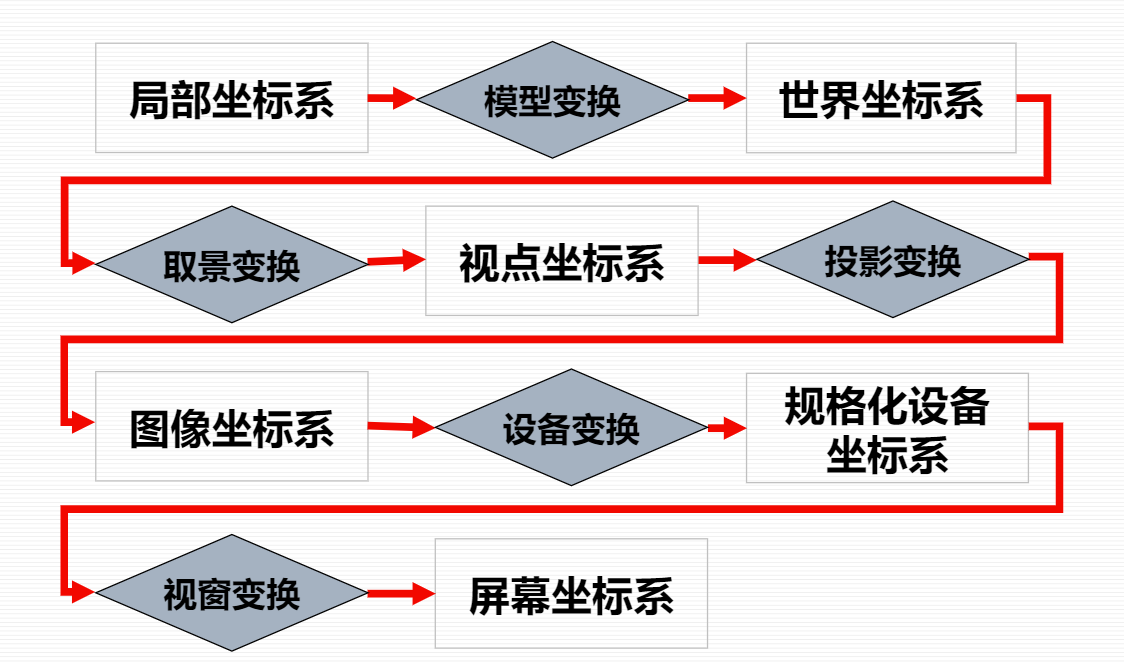

### 4.投影变换

#### 平行投影

略

#### 透视投影

- 灭点:3D物体的一组平行线投影后收敛于一点,称为灭点.
- 主灭点:3D物体**平行于坐标轴的平行线**收敛产生的灭点.
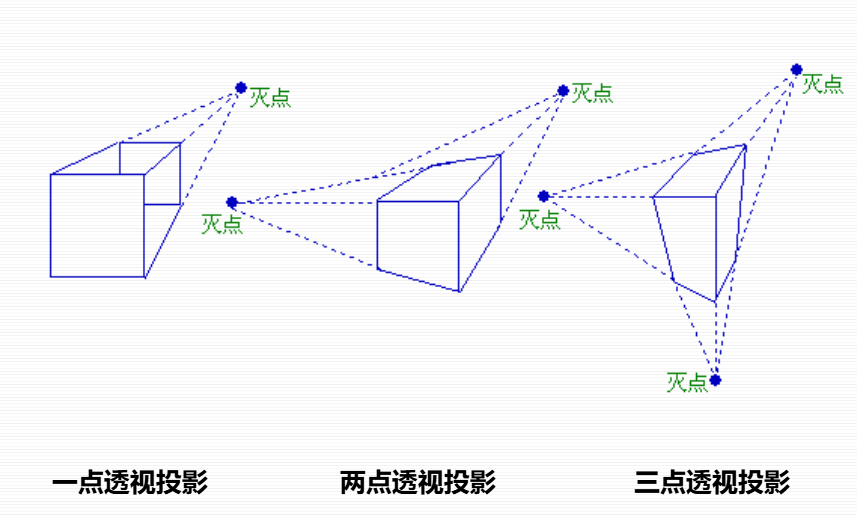

#### 一点,二点,三点透视

##### 一点透视

对变换:
$$ 
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0 \\
p & q & r & 1\\
\end{bmatrix}
\cdot 
\begin{bmatrix}x\\y\\z\\1\end{bmatrix}$$

令$p=r=0$,得到坐标$\begin{bmatrix}x\\y\\z\\qy+1\end{bmatrix}$.

齐次化后,当$y \to \infty$,有坐标$\begin{bmatrix}0\\\frac{1}{q}\\0\\1\end{bmatrix}$.所有点经过变换后均集中于Y轴上一点.称这一点为灭点$\begin{bmatrix}0\\\frac{1}{q}\\0\end{bmatrix}$.

同理,p,q,r分别不为零都有这个结果.

## 第六章:裁剪

### 1.裁剪操作在渲染pipeline中的位置

### 2.直线裁剪算法

#### Cohen-Sutherland裁剪算法

基本思想:对于每条待裁剪的线段$P_1P_2$,分三种情况:

- 若完全在窗口内,显示;
- 若完全在窗口外,丢弃;
- 否则:
  - 求线段与窗口边界的交点,在交点处把线段分为两段.
  - 其中一段在窗口外,丢弃,之后对另一端重复.

编码规则:

$$
\begin{align}
C_t(top) = \begin{cases}
1 & ,if y > y_{max}; \\
0 & ,otherwise.\\
\end{cases}
C_b(bottom) = \begin{cases}
1 & ,if y < y_{min}; \\
0 & ,otherwise.\\
\end{cases}\\
C_r(right) = \begin{cases}
1 & ,if x > x_{max}; \\
0 & ,otherwise.\\
\end{cases}
C_l(left) = \begin{cases}
1 & ,if x > x_{min}; \\
0 & ,otherwise.\\
\end{cases}
\end{align}
$$

对直线段的两端点,编码后:
- 若两端点编码全为0,则该直线段在窗口内,该直线段直接保留.
- 进行逻辑与运算:
  - 结果非0,说明该直线段在窗口外,直接舍弃.
  - 结果为0,需要求该直线和窗口边界的交点.
- 若需要求交:
  - 将两个端点进行逻辑或运算,根据1的位置来确定可能相交的窗口边.
  - 求交按照固定的顺序来,左右下上或上下右左.一条线段与窗口最多求交四次.
 
例如:

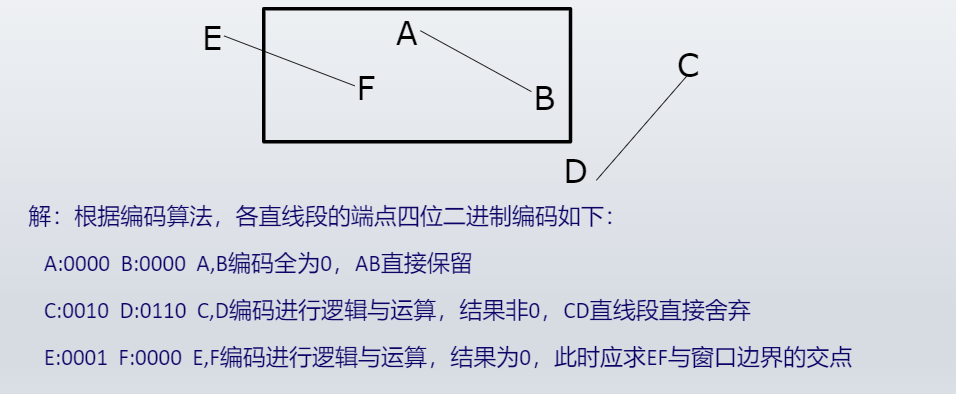

#### 中点分割算法

类似于Cohen-Sutherland算法:

- 将直线两端点$P_1,P_2$编码得到$C_1,C_2$.
- 全为0,说明两端点在窗口内,保留线段.
- $C_1 \& C_2 \neq 0$,表明两端点在窗口外同侧,线段全在窗口外,应该舍弃.
- 否则,求交点并进行裁剪.裁剪一端,得到最近可见点.求最近可见点:<mark>中点分割算法!</mark>
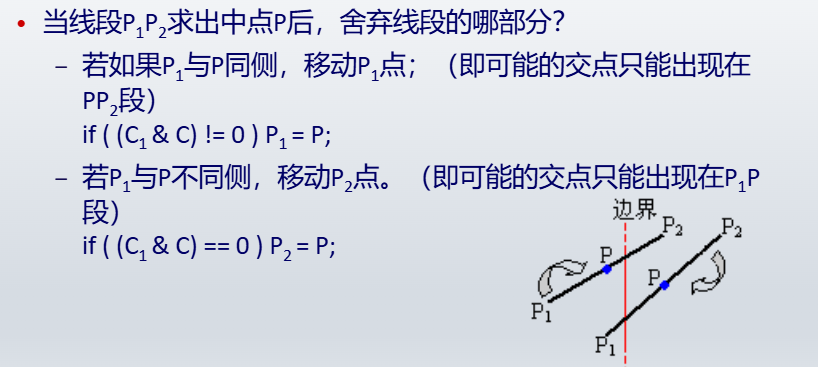

如此可收敛到最近可见点,即交点.

中点分割算法的特点:

- 求交点次数(n)于线段长度(L)有关,其关系为$L = 2^n$.例如,线段长度为256,则求交点次数为8.
- 求出的交点为边界上的有效交点,而非边界及其延长线上的交点(Cohen-Sutherland算法得到的交点为此类).
- 求中点:加法与除法,容易硬件实现.

#### 梁友栋-Barsky裁剪算法

对于直线段$P_0(x_1,y_1) \to P_1(x_2,y_2)$,直线上点的参数表示为:
$$
\begin{cases}
x = x_1 + u \ast (x_2 - x_1) = x_1 + u \ast \Delta x \\
y = y_1 + u \ast (y_2 - y_1) = y_1 + u \ast \Delta y
\end{cases}
(0 \leq u \leq 1.)
$$


计算四个交点的p,q,u.公式如下:
$$
\begin{align}
p_1 = -\Delta x, q_1 = x_1 - x_{left} \\
p_2 = \Delta x, q_2 = x_{right} - x _1 \\
p_3 = -\Delta y, q_3 = y_1 - y_{bottom} \\
p_4 = \Delta y, q_4 = y_{top} - y_1 \\
\end{align}
$$

- 当$p_i < 0$时,线段从裁剪边界的外部到内部:即这条边界为始边/入边.反之为终边/出边.
- 当$p_i = 0$时:
  - 若$q_i < 0$, 则$P_0pP_1$完全不可见.
  - 若$q_i > 0$,则$P_0P_1$平行于裁剪边界,并且至少部分在窗口内.

例如,当$\Delta x \geq 0$, 对于左边界,$p_1 < 0$,应该从左边界外部到内部,即左边界为入边.

边界交点的参数:
$$
u_i = \frac{q_i}{p_i},p_i \neq 0.
$$

最终,在入边交点,即$p_i < 0$的点中,取u最大的点.在出边交点,即$p_i > 0$的点中,取u最小的点.就得到这条直线段裁剪后的两个端点.再将该u值代入直线的参数方程中,就可以得到最终两个端点的坐标.

- 特点
  - 通常比Cohen-Sutherland算法效率更高.这种算法每次求交都要作除法.
 
#### 多边形裁剪
 
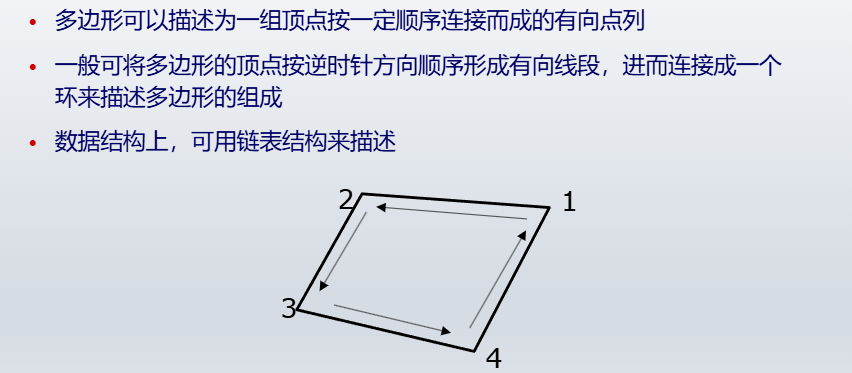
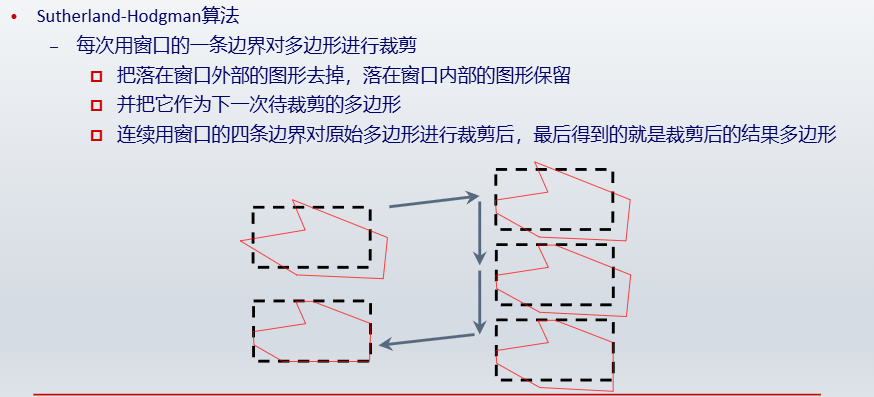
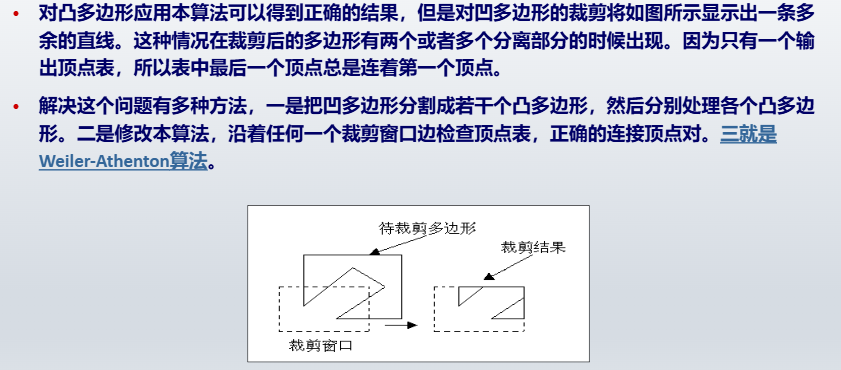

##### WA任意多边形裁剪算法

| step i | 内容|
| --- | -----------|
| 1 | 顺时针输入待裁剪多边形顶点序列I到数组1中. |
| 2 | 顺时针输入待裁剪窗口顶点序列II到数组2中. |
| 3 | 求出所有交点,并标注出该交点是"入"还是"出".然后将交点按照顺序插入序列I得到新的序列III,放入数组3中.同样将交点按顺序放入序列II得到序列IV,放入数组4中.|
| 4 | 初始化输出数组Q,令其为空.接着从数组3(插入了交点的多边形顶点序列)中寻找入点.若没有入点,$end!$.|
| 5 | 如果找到入点,将入点放入s中暂存.|
| 6 | 将入点记录到Q中,并从数组3中将该点的入标记删去.|
| 7 | 按照数组3顺序取顶点:$\begin{cases}如果顶点不是出点,则将顶点录入到数组Q中,goto \ step 7.\\else,goto \  step 8.\end{cases}$|
| 8 | 按照数组4顺序取顶点:$\begin{cases}如果顶点不是入点,则将顶点录入到Q中,goto \ step 8.\\else,goto \  step 9.\end{cases}$ |
| 9 | $\begin{cases}如果顶点不等于起始点s,goto \ step 6, 继续跟踪数组3.\\else,输出数组Q,goto \  step 4(可能结束,也可能找到下一个窗口内的多边形).\end{cases}$ |

注意:
- step 7,step 8的顶点顺序再步骤跳转时会继承.例如再第七步取到顶点b,此时b是出点,故跳转到第八步,依照数组4的顺序**从b开始**继续取顶点.
- 裁剪窗口顶点一定不是出点或者入店,所以遇到窗口顶点都会加入Q中.
- 3遇到不出加,4遇到不入加.否则跳.
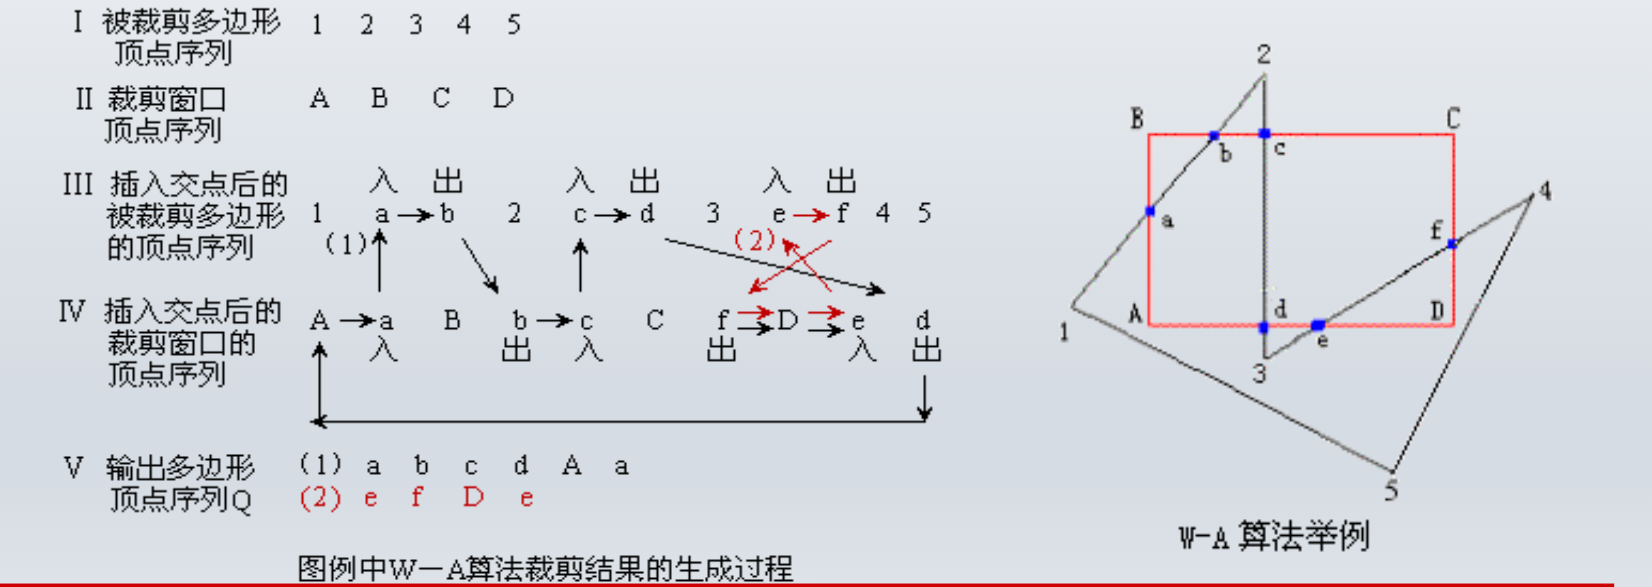


## 第七章:光栅化

多边形的两种表示方式:

- 顶点表示:用多边形的有序顶点序列表示多边形.
  - 优点:
    - 直观
    - 集合意义明显
    - 存储量小
  - 不足:
    - 难以判断哪些像素位于多边形内部
    - 不能直接用于多边形着色
- 点阵表示:用多边形内部像素集合来表示多边形.
  - 优点
    - 便于用帧缓冲器(frame buffer)表示图形.
    - 面着色所需的图形表示.
  - 缺点
    - 丢失了几何信息
    - 占用存储空间多.

多边形的扫描转换:

- 从多边形的给定边界出发,求出内部的各个像素.
- 并给帧缓冲器中各个对应元素设置相应灰度或颜色.

### 1. 区域填充算法

区域的定义:已经表示成点阵的像素集合.

区域的表示:

- 内部表示:把区域内的像素枚举出来.
  - 区域内所有像素着同一种颜色.
  - 区域边界像素不能着上述颜色.
- 边界表示:把区域边界上的像素枚举出来.
  - 边界上所有像素都着同一种颜色.
  - 区域内部像素不能着上述颜色.

内部表示区域种子填充算法:

- 假设内部表示区域为$G$,其中像素原有颜色为$G_0$,需要填充的颜色为$G_1$.
- 算法需要提供一个种子点$(x,y)$,它的颜色为$G_0$.
- 四连通区域的算法如下(左上右下):
  
~~~C
Flood_Fill_4(x, y, G0, G1){	
    if(GetPixel(x,y) == G0 ) // GetPixel(x,y) 返回(x,y)的颜色
                             // 如果已经涂色,此时返回G1,则不会再次涂色.
    {		
        SetPixel(x, y, G1);  //将(x,y)的添上颜色G1	    	
        Flood_Fill_4(x-1, y, G0, G1);		
        Flood_Fill_4(x, y+1, G0, G1);		 		
        Flood_Fill_4(x+1, y, G0, G1); 		
        Flood_Fill_4(x, y-1, G0, G1);	
    }
}
~~~

可以看作按照给定顺序入栈,在出栈时涂色.涂色时再将被涂色块四个方向的像素入栈(若已经涂色则不用入栈).

### 多边形的扫描转换

#### 逐点判断算法:逐个像素判别其是否位于多边形内部.
- 判断一个点是否位于多边形内部: <font color="red">射线法</font>
  - 从当前像素发射一条不经过顶点的射线,计算射线与多边形的交点个数.
    $$
    \begin{cases}
    有奇数个交点 \to 在内部. \\
    有偶数个交点 \to 在外部. \\ 
    \end{cases}
    $$

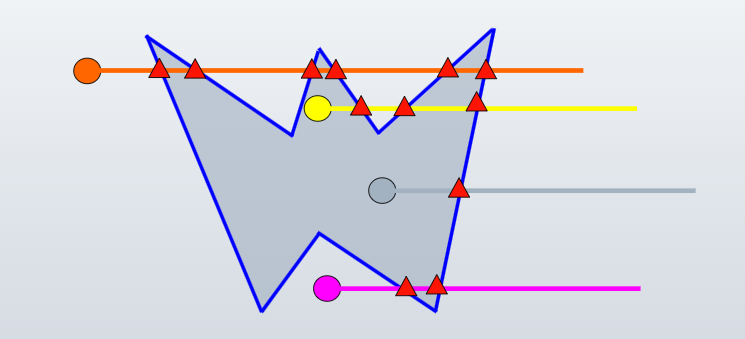

#### 扫描线算法

- 区域连贯性
  - 区域的连贯性是指多边形定义的区域内相邻的像素具有相同的性质.例如具有相同的颜色:
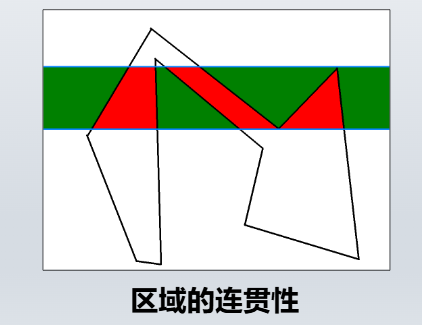

  - 两条扫描线之间的长方形区域被所处理的多边形分割成若干梯形(三角形可以看作退化梯形)。梯形的底边为扫描线，梯形的腰为多边形的边或窗口边缘。
  - 梯形分为两类：多边形内部和多边形外部。两类梯形在多边形内部相间排列(相邻的两个梯形必然有一个位于多边形内部，有一个在多边形外部)。
 
- 扫描线连贯性
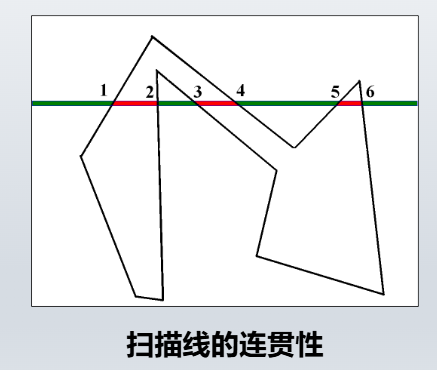
  - 交点序列:扫描线与多边形的交点个数为偶数.
  - 区间相间排列.

- 边的连贯性
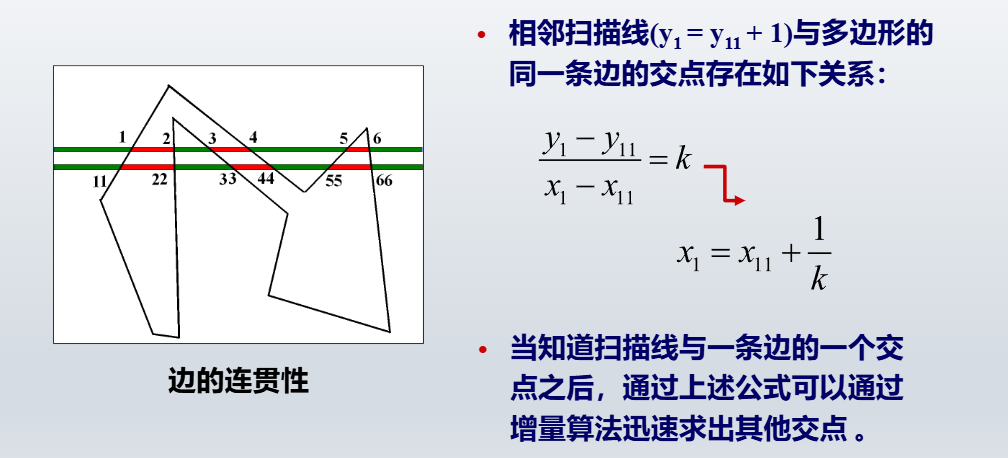

- 奇异点
 - 定义:扫描线与多边形交于多边形的顶点.
 - 计数规则:
$$
\begin{cases}
交点是极值点(包括交点在内的三个相邻顶点都在扫描线同侧) \to 计为两个交点 \\
otherwise \to 计为一个交点.\\
\end{cases}
$$

- 算法核心思想(从下到上扫描)

  - 计算扫描线$y=y_{min}$与多边形的交点,通常这些交点由多边形的顶点组成.
  - 根据<font color="red">边的连贯性</font>,按照从下到上的顺序求得各条扫描线的交点序列.
  - 根据<font color="red">区域和扫描线的连贯性</font>判断位于多边形内部的区段.
  - 对内部直线段进行着色.

为了实现上述四项,算法中需要采取灵活的数据结构.

- 分类的边表ET(Sorted Edge Table):记录多边形信息.
- 活化边链表AEL(Active Edge List):记录当前扫描线信息.

它们的共同基础是边的数据结构.


~~~C
struct edge{
    int y_max; //边的上端点的y坐标
    int x;  //边下断点的x坐标.
            //在AEL中,表示扫描线与边的交点的x坐标
    float dx; //边的斜率的倒数
    struct edge* next;
};
~~~

- 分类的边表(ET)是按边的下断点的y坐标对非水平边进行分类的指针数组.
  - 下端点$y = i$的边,归入第i类;
  - 同一类中,各边按x递增(x相等则按照dx的值排序)的顺序排成一行.
  - 水平边不加入ET.
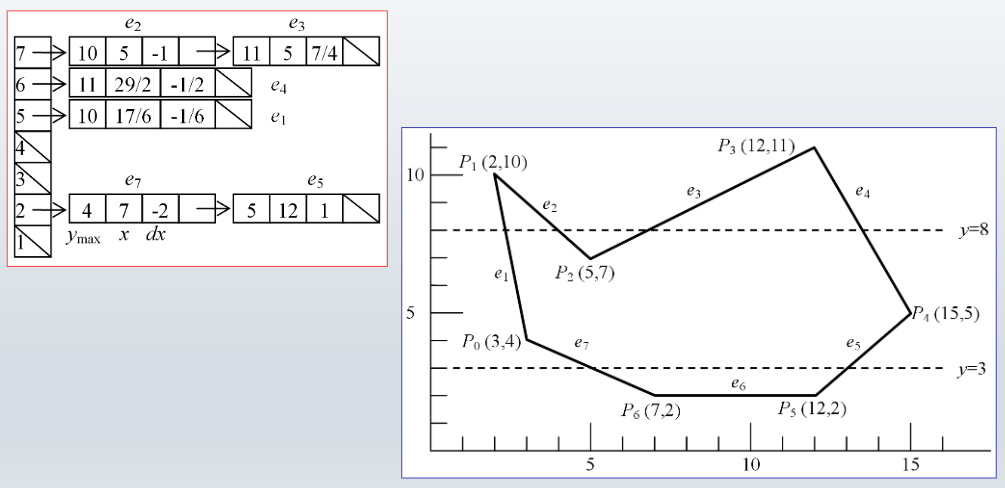

- 活化边链表(AEL)由与当前扫描线相交的边组成.

  - 记录了多边形的边沿扫描线的交点序列.
  - 根据边的连贯性不断刷新交点序列.
  - 基本单元是与扫描线相交的边.
  - 分类边表ET记录初始状态.活化边表AEL随扫描线的移动动态更新.
  - 注意在AEL中,x不再代表相交的边下端点的x坐标,而是代表<font color = "red">交点的x坐标</font>.
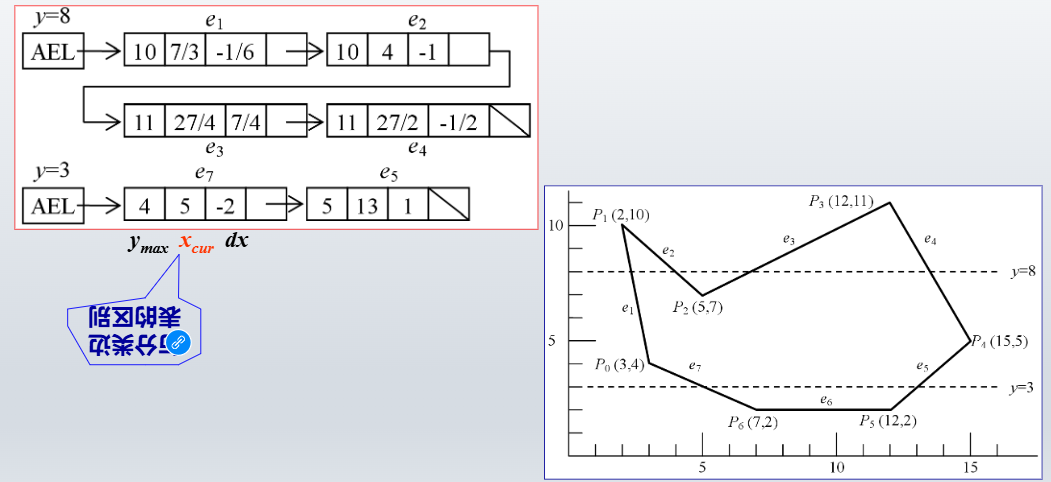

- 多边形扫描转换算法步骤

  1. (y初始化)取扫描线纵坐标y的初始值为ET中非空元素的最小序号.例子中y=2.
     
     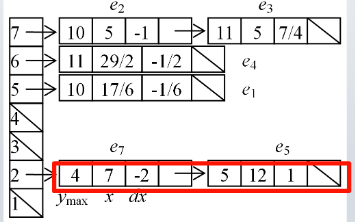
     
  2. (AEL初始化)将边的活化链表AEL设置为空.
  3. 按从下到上的顺序对纵坐标值为y的扫描线(当前扫描线)执行如下步骤,直到分类边表ET和边的活化链表AEL都变成空为止.
     1. 如果ET中第y类元素非空,则将属于该类中所有边从ET中取出(并删除),并插入AEL中.
     2. 对当前扫描线,边的AEL非空,则将AEL中边交点两两依次配对.每一对边与当前扫描线的交点区间位于多边形内部,并对这些区间上的像素着色.
     3. 将AEL中满足$y = y_{max}$的边删除.
     4. 将AEL中剩下的每条边x加dx,即$x' = x + dx$.
     5. 将当前扫描线纵坐标y加1,即$y' = y + 1$.

多边形扫描转换的优点:

- 充分利用多边形区域,扫描线及边的连贯性,避免了反复求交的大量运算.

不足:

- 算法的数据结构和程序结构复杂.
- 对各种表的维持和排序开销大,适合软件实现而不适合硬件实现.

<font color = "red">注:过极值点时,上方看作断开纵坐标一单位长度.同时x坐标也要相应变化!这点在ET和AEL中都要注意!!!</font>

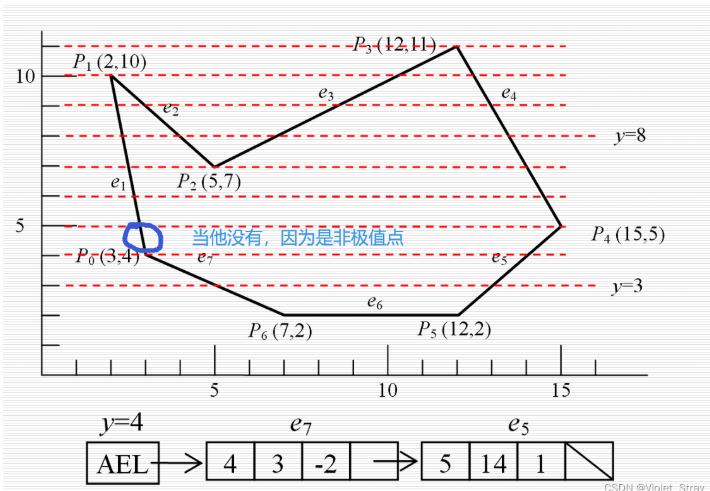


## 第八章:消隐

### 1.图像空间消隐算法

~~~C
for (each pixel in the image){
    connect the pixel and the viewpoint find the nearest object;
    compute the color of that pixel;
    }
~~~

- 受分辨率限制
- 时间复杂度$O(nN)$:
  - 每个像素都需要对物体排序,
  - n:多边形数;
  - N:像素个数;
- 此类算法:z-buffer,scan line algorithm

### 2.对象空间消隐算法

~~~C
for (each object in world coordinate space){
    1. detemine its portion which does not occluded by others;(确定未被遮挡的部分)
    2. find the pixel using scan conversion algorithms;
    3. compute the color of the pixels;
    }
~~~

- 适合精密CAD工程领域
- 复杂度$O(n^2)$
  - n:对象数
- Back surface culling
- 画家算法:
  - 1.排序:将所有要绘制的物体按照到观察者的距离排序.
  - 2.逐个绘制:从远到近绘制物体.因此靠近的(可见的)会遮盖较远的物体.

### Z-buffer算法

~~~C
1. 初始化背景色c-buffer; // 这是屏幕上每个像素的颜色存储区.初始被清空或设置为背景色.
2. 初始化z-buffer; // 这是一个与颜色缓冲区大小相同的数组.
                    // 记录每个像素点的深度z.表示离观察者的远近.
                    // 初始被设置为最大值,表示最远距离.
3. for(每个多边形F){
    for(F中每一个像素(x,y)){
        计算z(x,y); //算出z值:深度
        if(z(x,y) < z-buffer(x,y)){ //当前像素z值更小,说明更近
            c-buffer(x,y) = 计算光亮值属性; //修改c-buffer
            z-buffer(x,y) = z(x,y); //更新z-buffer
        }
    }
}
~~~

计算z值的方法如下:公式形式类似相似三角形比例关系写法.
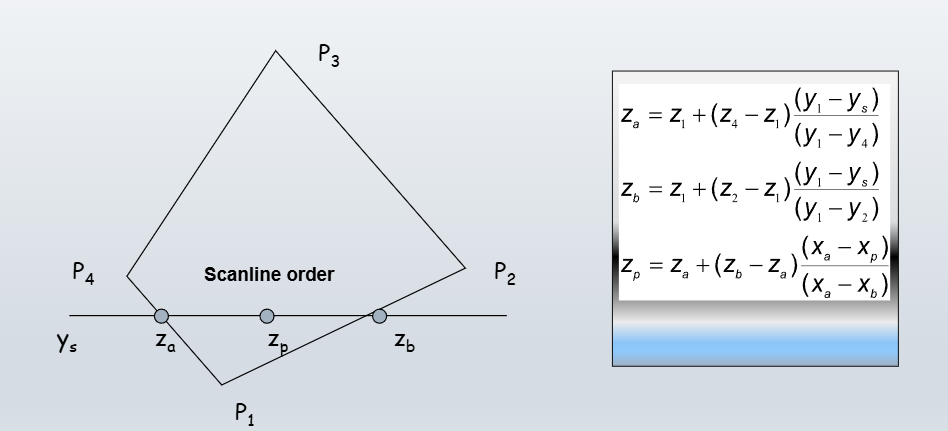

优缺点:
- 复杂度:$O(nN)$.
- 不需要物体排序.
- 能够处理任意几何形状.
- 可以使用硬件加速.
缺点:
- Z-buffer很大.占用显存.
- 受限分辨率,存在走样
- 不好处理透明物体

### 二叉空间剖分树(Binary Space Partitioning)(BSP树)

- 如果场景中的多边形可以被一个平面分割成两部分,<font color = "red">与视点同侧的物体不会被与视点异侧的物体遮挡</font>
- 对位于分割平面两侧的多边形继续进行递归分割,直到一个分割平面两侧或一侧只有一个多边形.
- 适用于视点变化场景不变的绘制.

用两个例子来说明BSP树的结构.

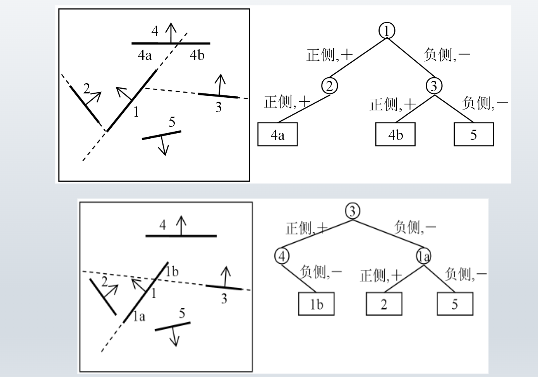

在得到了场景的BSP树之后,遍历BSP树进行绘制.可以从后往前绘制,也可以从前往后绘制.

如果从前往后绘制,则被绘制的像素不再次被上色.

从后往前,相当于在每个子空间里使用画家算法.

~~~C
void showBSP(viewer,T){
    if(T is empty)
        return;
    P = root of T;
    if(viewer is in front of P){
        showBSP(viewer,back subtree of T);
        draw P;
        showBSP(viewer,front subtree of T);
    }else{
        showBSP(viewer,front subtree of T);
        draw P;
        showBSP(viewer,back subtree of T);
    }
}
~~~

##  